**Nikhil Sunder**  
ICSRI Research Fellow, University of Miami | Open-Source Developer  
Herbert Business School, University of Miami  
B.S.B.A. Quantitative Economics & Finance; Minor in Mathematics  

**Correspondence:** nss106@miami.edu  
**Research profiles:** [GitHub](https://github.com/nikhilxsunder) · [ORCID](https://orcid.org/0009-0007-3323-1760) · [LinkedIn](https://www.linkedin.com/in/nikhil-sunder/) · [Zenodo](https://zenodo.org/search?q=metadata.creators.person_or_org.name:%22Sunder,+Nikhil%22)  
**Software:** [PyPI](https://pypi.org/user/nikhil.sunder/) · [Anaconda](https://anaconda.org/nikhil.sunder/)

# 6. Non-linear economy: the neural state-space model

The modern non-linear specification: a two-block neural state-space model whose latent states carry
information across quarters, estimated on the full-information inputs. The notebook closes with the
comparison of the three fixed economies (SVAR, NARX, NSSM).

**Inputs:** `artifacts/data/`, the one-step fits of notebooks `01_linear_svar` and `05_nonlinear_narx`.
**Outputs:** `artifacts/nonlinear/nssm.pt` (model, latent states and shock scales, for the
reinforcement-learning notebooks) and `artifacts/nonlinear/one_step_nssm.csv`.

The classes and functions the text describes (the model, its input sequences, the training loop) are defined in `autofed.nonlinear`; this notebook configures and calls them.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

import autofed as af
from autofed import linear as lin
from autofed import nonlinear as nl
from autofed import plots
from autofed.style import COLORS

nb = af.NotebookSession(
    "06_nonlinear_nssm", number=6, title="Non-linear economy: the neural state-space model"
)
panel = af.load_macro_panel(nb.artifacts("data"))
cfg = panel.config
df_train, df_all = panel.train, panel.full
svar_fit = af.load_frame(
    nb.artifacts("linear") / "one_step_fixed.csv", producer="notebook 01_linear_svar"
)
print(
    f"Data vintage {panel.retrieved} | training {df_train.index[0]}-{df_train.index[-1]} | "
    f"full {df_all.index[0]}-{df_all.index[-1]} | torch {torch.__version__}"
)


def squared(frame: pd.DataFrame, column: str) -> pd.Series:
    return (frame[column] - frame[f"{column}_hat"]) ** 2


def mse_row(frame: pd.DataFrame) -> dict[str, float]:
    mse_y, mse_pi = float(squared(frame, "y").mean()), float(squared(frame, "pi").mean())
    return {
        "MSE output gap": mse_y,
        "MSE inflation": mse_pi,
        "MSE total": 0.5 * (mse_y + mse_pi),
    }


narx_fit = af.load_frame(
    nb.artifacts("nonlinear") / "one_step_narx.csv", producer="notebook 05_nonlinear_narx"
)

Data vintage 2026-10-07 | training 1987Q3-2007Q2 | full 1987Q3-2026Q2 | torch 2.14.1


# Modern Specification: Neural State Space Model

To extend the nonlinear environment beyond static function approximation, we introduce a neural state space model (NSSM). This specification generalizes the classical state-space framework by allowing nonlinear transition and measurement mappings parameterized by neural networks rather than fixed linear operators (Durbin & Koopman, 2012; Fraccaro et al., 2016).

Relative to the NARX specification, which maps explicit lagged observables into current outcomes, the NSSM introduces a latent state that evolves recursively through time. This provides a more modern dynamical representation of the economy while retaining a compact recursive system suitable for forecasting and policy-environment approximation (Krishnan et al., 2017; Rangapuram et al., 2018).

## State-space formulation

Let $h_t^y \in {\mathbb{R}^{d_y}}$ and $h_t^\pi \in \mathbb{R}^{d_\pi}$ denote equation-specific latent states for the output-gap and inflation blocks, respectively. To maintain comparability with the full-information benchmark system, the neural state-space model uses the same full regressor sets as the unrestricted second-order linear environment.

Define

$$
s_t^y = (y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2}),
$$

and

$$
s_t^\pi = (y_t, y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2}).
$$

The deterministic neural state-space system is then written as

$$
\begin{aligned}
h_t^y &= f_y(h_{t-1}^y, s_t^y), \\
y_t &= g_y(h_t^y),
\end{aligned}
\qquad
\begin{aligned}
h_t^\pi &= f_\pi(h_{t-1}^\pi, s_t^\pi), \\
\pi_t &= g_\pi(h_t^\pi).
\end{aligned}
$$

This preserves the recursive macroeconomic logic of the earlier environments while replacing explicit lag stacks with a learned latent state (Durbin & Koopman, 2012; Fraccaro et al., 2016).

## Relation to the linear and NARX environments


The NSSM preserves the full observable information set used in the unrestricted second-order system, while introducing latent states that evolve dynamically over time.

In contrast to the earlier NARX specification, which treats the mapping from lagged variables to current outcomes as static, the NSSM allows for dynamic nonlinear propagation through the latent state. At the same time, by retaining the full regressor vectors $ s_t^y $ and $ s_t^\pi $, the model avoids placing excessive informational burden on the latent state.

This hybrid structure can therefore be interpreted as a state-space generalization of the nonlinear regression model, rather than a fully latent system (Krishnan et al., 2017; Rangapuram et al., 2018).

## Deterministic training setup

Given the limited sample size, we estimate a deterministic version of the NSSM. That is, we omit explicit stochastic disturbance terms and instead train the model via supervised sequence fitting.

This approach avoids the additional complexity of latent-state inference while retaining the key advantage of the state-space formulation: recursive temporal structure (Fraccaro et al., 2016; Krishnan et al., 2017).

## Functional parameterization

We parameterize the transition and emission equations using shallow neural mappings:

$$
\begin{aligned}
h_t^y &= \operatorname{SiLU}(W_h^y h_{t-1}^y + W_x^y s_t^y + b_h^y), \\
y_t &= W_o^y h_t^y + b_o^y,
\end{aligned}
$$

and

$$
\begin{aligned}
h_t^\pi &= \operatorname{SiLU}(W_h^\pi h_{t-1}^\pi + W_x^\pi s_t^\pi + b_h^\pi), \\
\pi_t &= W_o^\pi h_t^\pi + b_o^\pi.
\end{aligned}
$$

The transition nonlinearity is the Sigmoid Linear Unit (SiLU), defined as

$$
\operatorname{SiLU}(x) = x \cdot \sigma(x).
$$

SiLU is chosen because it is smooth, differentiable, and empirically effective in modern neural architectures, while avoiding the saturation behavior of earlier bounded nonlinearities such as tanh (Elfwing et al., 2018; Ramachandran et al., 2018).

## Initialization strategy

The transition matrices $W_h^y$ and $W_h^\pi$ are initialized orthogonally, while the input and emission layers use Xavier initialization.

Orthogonal initialization is particularly natural for latent transition operators because it helps preserve signal scale and improves optimization in sequential or recurrent settings (Saxe et al., 2014; Hu et al., 2020). Xavier initialization is used for the remaining linear layers to stabilize variance propagation across inputs and outputs (Glorot & Bengio, 2010).

This combination provides a modern alternative to the Nguyen–Widrow initialization used in the earlier shallow NARX section.

## Optimization

The NSSM is estimated using AdamW rather than Levenberg–Marquardt. AdamW decouples weight decay from the gradient update and is now a standard first-order optimizer for modern neural-network training (Loshchilov & Hutter, 2019).

The training objective is the joint mean squared error across the two observed macroeconomic series:

$$
\mathcal{L}
=
\frac{1}{T}
\sum_{t=1}^{T}
\left[
(y_t - \hat{y}_t)^2
+
(\pi_t - \hat{\pi}_t)^2
\right].
$$

Because the model is recursive in the latent state, training is carried out over the full sequence rather than on independent observations.

In [2]:
DTYPE = torch.float64
DEVICE = torch.device("cpu")
torch.use_deterministic_algorithms(True)

## Sequence propagation

The NSSM is evaluated recursively over the lag-aligned sample by iterating the transition equation forward through time. At each quarter, the latent state is updated using the previous latent state and the observed lagged policy rate, and the current output gap and inflation are obtained from the emission equations.

## Data used for the state-space model

To keep the NSSM directly comparable to the earlier nonlinear specification, we use the same lag-aligned sample span as the NARX environment. The sequence input is the lagged policy rate $ i_{t-1} $, while the targets are the realized output gap and inflation series over the same aligned quarters.

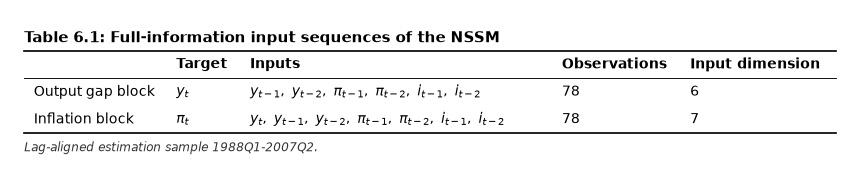

In [3]:
inputs = nl.build_full_nssm_inputs(df_train, dtype=DTYPE, device=DEVICE)
inputs_table = pd.DataFrame({
    "Output gap block": {
        "Target": r"$y_t$",
        "Inputs": r"$y_{t-1},\ y_{t-2},\ \pi_{t-1},\ \pi_{t-2},\ i_{t-1},\ i_{t-2}$",
        "Observations": inputs.X_y.shape[0],
        "Input dimension": inputs.X_y.shape[1],
    },
    "Inflation block": {
        "Target": r"$\pi_t$",
        "Inputs": r"$y_t,\ y_{t-1},\ y_{t-2},\ \pi_{t-1},\ \pi_{t-2},\ i_{t-1},\ i_{t-2}$",
        "Observations": inputs.X_pi.shape[0],
        "Input dimension": inputs.X_pi.shape[1],
    },
}).T
nb.table(
    inputs_table,
    "nssm_inputs",
    "Full-information input sequences of the NSSM",
    note=f"Lag-aligned estimation sample {inputs.time_index[0]}-{inputs.time_index[-1]}.",
)

## Model estimation

The NSSM is estimated using the AdamW optimizer, which decouples weight decay from gradient updates and improves generalization relative to standard Adam (Loshchilov & Hutter, 2019).

The objective function is the joint mean squared error:

$$
\mathcal{L}
=
\frac{1}{T}
\sum_{t=1}^{T}
\left[
(y_t - \hat{y}_t)^2
+
(\pi_t - \hat{\pi}_t)^2
\right].
$$

Training is performed over the full sequence, preserving the recursive evolution of the latent state.

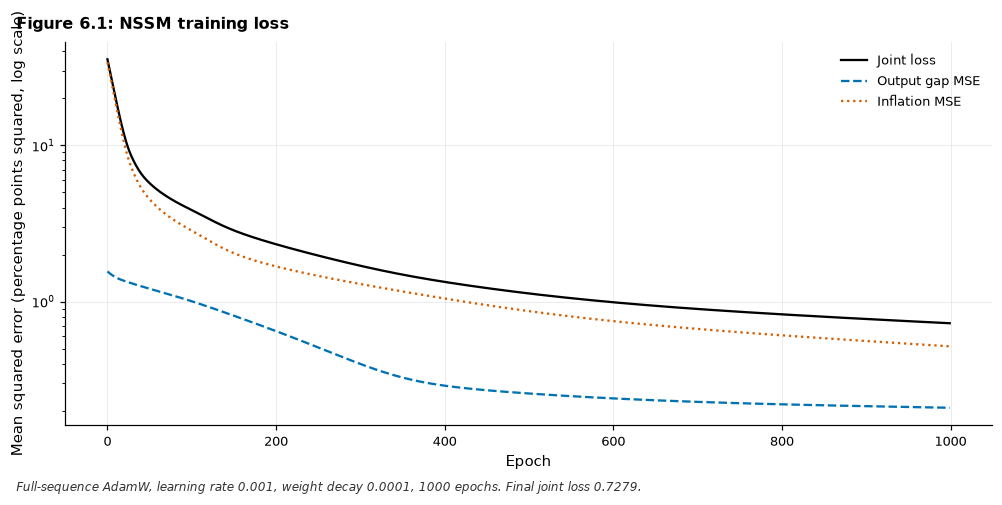

In [4]:
STATE_DIM_Y = STATE_DIM_PI = 4
EPOCHS = 1000
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
SEED = 2026  # weight initialisation

training = nl.train_nssm(
    inputs,
    state_dim_y=STATE_DIM_Y,
    state_dim_pi=STATE_DIM_PI,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    seed=SEED,
)
history = training.loss_history

fig, ax = plt.subplots()
ax.plot(history.index, history["total"], color=COLORS["black"], label="Joint loss")
ax.plot(history.index, history["y"], color=COLORS["blue"], ls="--", label="Output gap MSE")
ax.plot(history.index, history["pi"], color=COLORS["vermillion"], ls=":", label="Inflation MSE")
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean squared error (percentage points squared, log scale)")
ax.legend()
nb.figure(
    fig,
    "nssm_training_loss",
    "NSSM training loss",
    note=(
        f"Full-sequence AdamW, learning rate {LEARNING_RATE:g}, weight decay {WEIGHT_DECAY:g},"
        f" {EPOCHS} epochs. Final joint loss {history['total'].iloc[-1]:.4f}."
    ),
)

## Fitted values and diagnostics

To maintain comparability with the linear and NARX environments, fitted values are collected in a single aligned dataframe and converted into squared-error diagnostics for both equations.

The fitted model is wrapped with its latent states: the initial state (zeros), and the state reached at
the last estimation-window quarter, which anchors the reinforcement-learning rollouts. The shock scales
are the residual standard deviations over the estimation window.

In [5]:
economy = nl.NSSMEconomy.from_training(
    training,
    df_train,
    sample=f"{cfg.train_start}-{cfg.train_end}",
    vintage=panel.retrieved,
    epochs=EPOCHS,
    seed=SEED,
)
fit_all, states_y_all, states_pi_all = economy.run(
    df_all
)  # one pass over estimation + out-of-sample
fit_nssm = fit_all.loc[: cfg.train_end]
assert torch.equal(economy.terminal_y, states_y_all[len(fit_nssm) - 1 : len(fit_nssm)])

print(
    "Saved", economy.save(nb.artifacts("nonlinear") / "nssm.pt").relative_to(nb.workspace.root)
)
print(
    "Saved",
    af.save_frame(fit_all, nb.artifacts("nonlinear") / "one_step_nssm.csv").relative_to(
        nb.workspace.root
    ),
)
print(
    f"Residual standard deviations: output gap {economy.sigma_y:.4f}, inflation"
    f" {economy.sigma_pi:.4f}"
)

Saved artifacts/nonlinear/nssm.pt
Saved artifacts/nonlinear/one_step_nssm.csv
Residual standard deviations: output gap 0.4608, inflation 0.6987


## Economy fit: mean squared errors

As in the ANN section above, we summarize the NSSM fit using equation-specific and overall mean squared errors.

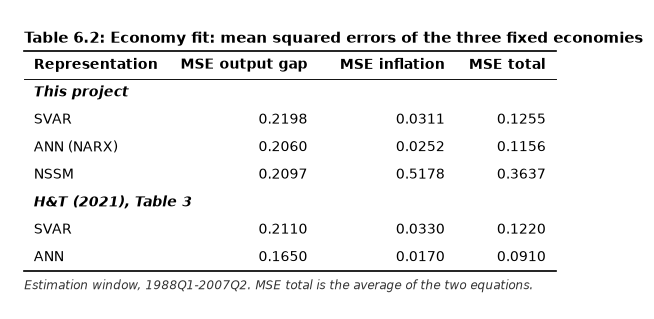

In [6]:
svar_is, narx_is = svar_fit.loc[fit_nssm.index], narx_fit.loc[fit_nssm.index]
PAPER_TABLE3 = {
    "SVAR": {"MSE output gap": 0.211, "MSE inflation": 0.033, "MSE total": 0.122},
    "ANN": {"MSE output gap": 0.165, "MSE inflation": 0.017, "MSE total": 0.091},
}
mse_table = pd.concat(
    {
        "This project": (
            pd.DataFrame({
                "SVAR": mse_row(svar_is),
                "ANN (NARX)": mse_row(narx_is),
                "NSSM": mse_row(fit_nssm),
            }).T
        ),
        "H&T (2021), Table 3": pd.DataFrame(PAPER_TABLE3).T,
    },
    names=["Source", "Representation"],
)
nb.table(
    mse_table,
    "economy_fit",
    "Economy fit: mean squared errors of the three fixed economies",
    float_format="{:.4f}",
    note=(
        f"Estimation window, {fit_nssm.index[0]}-{fit_nssm.index[-1]}. MSE total is the average"
        " of the two equations."
    ),
)

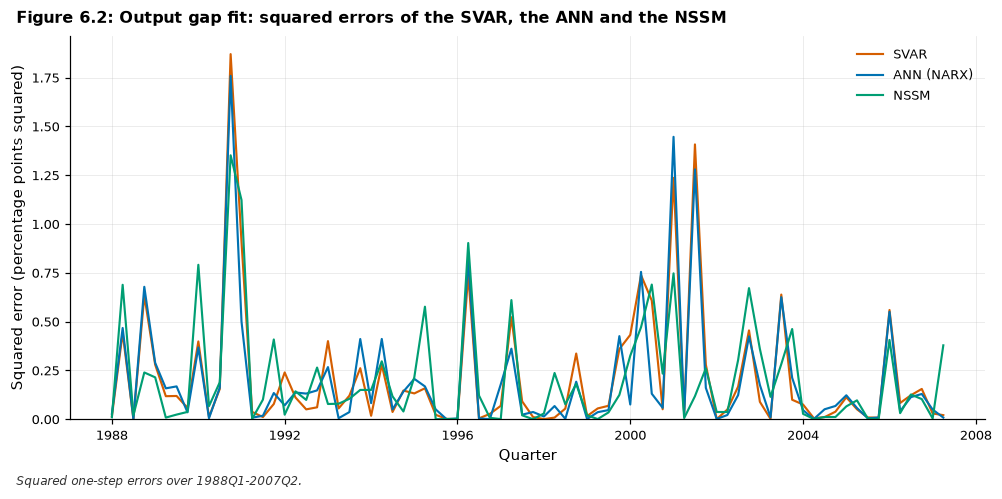

In [7]:
fig = plots.squared_errors({
    "SVAR": squared(svar_is, "y"),
    "ANN (NARX)": squared(narx_is, "y"),
    "NSSM": squared(fit_nssm, "y"),
})
nb.figure(
    fig,
    "in_sample_se_output_gap",
    "Output gap fit: squared errors of the SVAR, the ANN and the NSSM",
    note=f"Squared one-step errors over {fit_nssm.index[0]}-{fit_nssm.index[-1]}.",
)

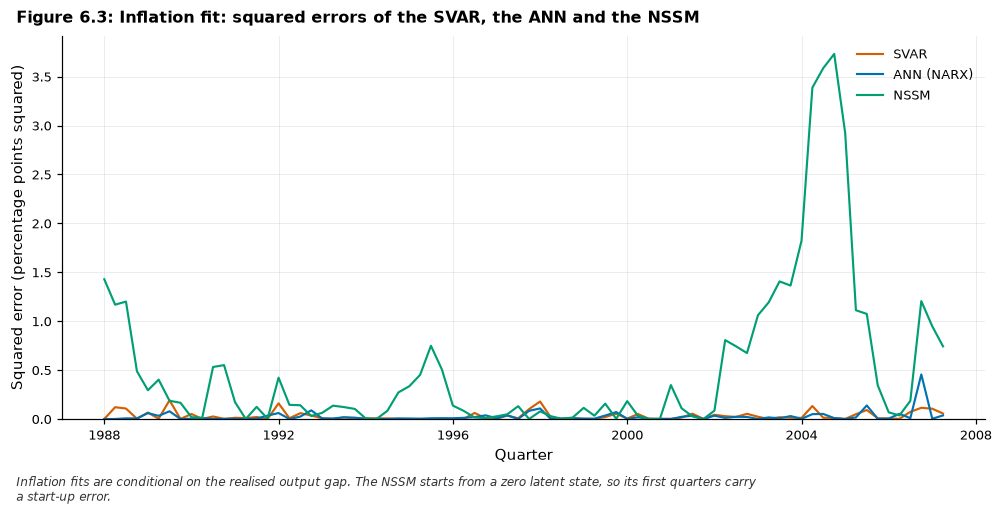

In [8]:
fig = plots.squared_errors({
    "SVAR": squared(svar_is, "pi"),
    "ANN (NARX)": squared(narx_is, "pi"),
    "NSSM": squared(fit_nssm, "pi"),
})
nb.figure(
    fig,
    "in_sample_se_inflation",
    "Inflation fit: squared errors of the SVAR, the ANN and the NSSM",
    note=(
        "Inflation fits are conditional on the realised output gap. The NSSM starts from a zero"
        " latent state, so its first quarters carry a start-up error."
    ),
)

## State-Conditioned Response Surface — NSSM Inflation

Because the neural state-space model evolves through a latent recursive state, a standard partial dependence surface is less informative than in the earlier NARX setting. Instead, we construct a **state-conditioned response surface**.

The idea is to fix the inflation block's latent state at a chosen historical quarter and then vary selected observed inputs while holding the remaining regressors fixed at their anchor-quarter values. The resulting surface shows how the fitted NSSM maps those inputs into the next inflation prediction **conditional on the chosen latent state**.

This is therefore a local state-dependent visualization of the nonlinear state-space environment rather than a global static partial dependence object.

To make the visualization concrete, we select one historical anchor quarter from the fitted sample. The latent state from that quarter is held fixed, and the remaining surface is computed relative to that anchor configuration.

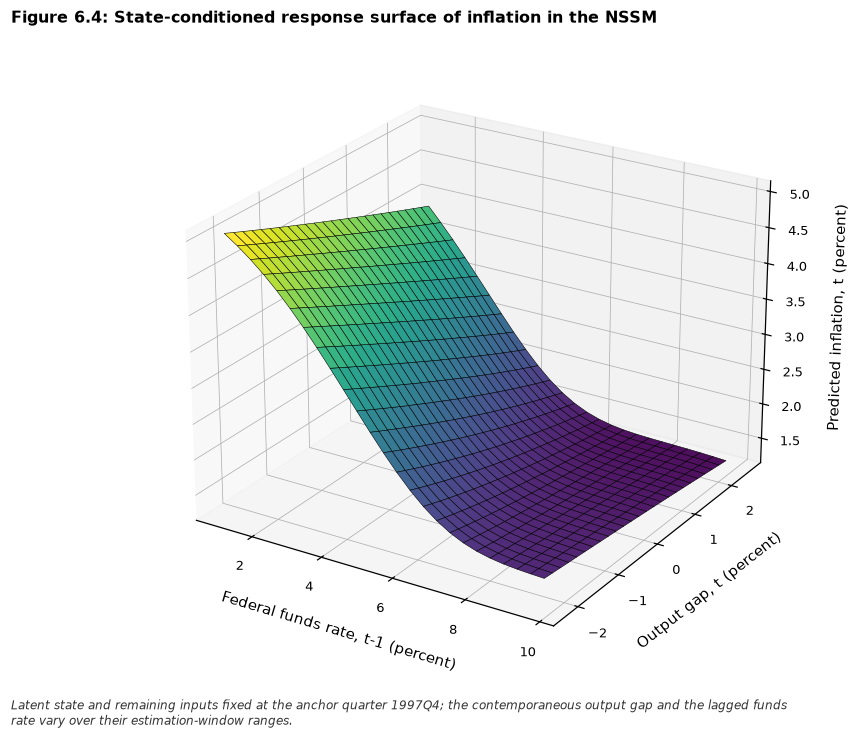

In [9]:
# Anchor quarter: midpoint of the lag-aligned estimation sample.
anchor = len(inputs.time_index) // 2
anchor_period = inputs.time_index[anchor]
_, states_y, states_pi = economy.run(df_train)
h_y, h_pi = states_y[anchor : anchor + 1], states_pi[anchor : anchor + 1]
x_y, x_pi = inputs.X_y[anchor : anchor + 1], inputs.X_pi[anchor : anchor + 1]

GRID = 25
y_vals = np.linspace(df_train["y"].min(), df_train["y"].max(), GRID)
i_vals = np.linspace(df_train["i"].min(), df_train["i"].max(), GRID)
pi_vals = np.linspace(df_train["pi"].min(), df_train["pi"].max(), GRID)


def as_column(values: np.ndarray) -> torch.Tensor:
    return torch.tensor(values.ravel(), dtype=DTYPE, device=DEVICE)


# Inflation block inputs: (y_t, y_{t-1}, y_{t-2}, pi_{t-1}, pi_{t-2}, i_{t-1}, i_{t-2}).
# Vary y_t and i_{t-1}.
Y_GRID, I_GRID = np.meshgrid(y_vals, i_vals)
n = Y_GRID.size
x_pi_grid = x_pi.repeat(n, 1)
x_pi_grid[:, 0], x_pi_grid[:, 5] = as_column(Y_GRID), as_column(I_GRID)
with torch.no_grad():
    _, _, _, pi_grid = economy.model(
        h_y.expand(n, -1), h_pi.expand(n, -1), x_y.expand(n, -1), x_pi_grid
    )

fig = plots.surface(
    I_GRID,
    Y_GRID,
    pi_grid.reshape(Y_GRID.shape).cpu().numpy(),
    xlabel="Federal funds rate, t-1 (percent)",
    ylabel="Output gap, t (percent)",
    zlabel="Predicted inflation, t (percent)",
)
nb.figure(
    fig,
    "state_conditioned_inflation",
    "State-conditioned response surface of inflation in the NSSM",
    note=(
        f"Latent state and remaining inputs fixed at the anchor quarter {anchor_period}; the"
        " contemporaneous output gap and the lagged funds rate vary over their"
        " estimation-window ranges."
    ),
)

## State-Conditioned Response Surface — NSSM Output Gap

We next construct the analogous state-conditioned response surface for the output-gap block. Again, the latent state is fixed at the anchor quarter, while selected observed inputs are varied over their empirical support and the remaining regressors are held fixed.

This produces a local state-dependent visualization of the NSSM's output-gap mapping.

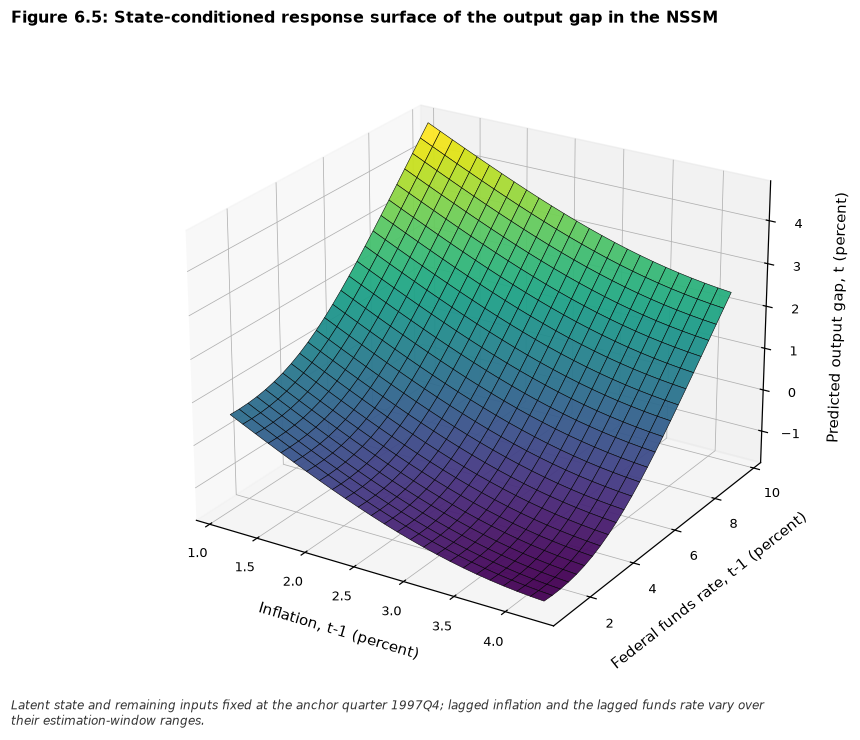

In [10]:
# Output-gap block inputs: (y_{t-1}, y_{t-2}, pi_{t-1}, pi_{t-2}, i_{t-1}, i_{t-2}).
# Vary pi_{t-1} and i_{t-1}.
PI_GRID, I_GRID = np.meshgrid(pi_vals, i_vals)
n = PI_GRID.size
x_y_grid = x_y.repeat(n, 1)
x_y_grid[:, 2], x_y_grid[:, 4] = as_column(PI_GRID), as_column(I_GRID)
with torch.no_grad():
    _, _, y_grid, _ = economy.model(
        h_y.expand(n, -1), h_pi.expand(n, -1), x_y_grid, x_pi.expand(n, -1)
    )

fig = plots.surface(
    PI_GRID,
    I_GRID,
    y_grid.reshape(PI_GRID.shape).cpu().numpy(),
    xlabel="Inflation, t-1 (percent)",
    ylabel="Federal funds rate, t-1 (percent)",
    zlabel="Predicted output gap, t (percent)",
)
nb.figure(
    fig,
    "state_conditioned_output_gap",
    "State-conditioned response surface of the output gap in the NSSM",
    note=(
        f"Latent state and remaining inputs fixed at the anchor quarter {anchor_period}; lagged"
        " inflation and the lagged funds rate vary over their estimation-window ranges."
    ),
)

## Out-of-Sample NSSM Fit — One-Step Actual vs Predicted Values

To evaluate the neural state-space model outside the estimation sample, we next generate one-step out-of-sample predictions over the post-2007 period.

Because the NSSM is a recursive latent-state model, the out-of-sample evaluation is constructed by propagating the fitted model forward over the full aligned sequence and then extracting the post-2007 segment. This preserves the latent-state history inherited from the training sample and therefore provides a more coherent out-of-sample assessment than restarting the model only at the beginning of the evaluation window.

As in the earlier NSSM specification, the inflation block uses the full-information regressor set, so this should be interpreted as a one-step conditional out-of-sample evaluation rather than a fully recursive counterfactual simulation.

The full NSSM input sequence is rebuilt over the combined training and out-of-sample panel. This is necessary because the latent state at each quarter depends on the earlier recursive history.

The combined input sequence is then passed through the retained fitted NSSM. The resulting predicted paths are aligned with the full lag-adjusted sample, after which the out-of-sample segment is extracted.

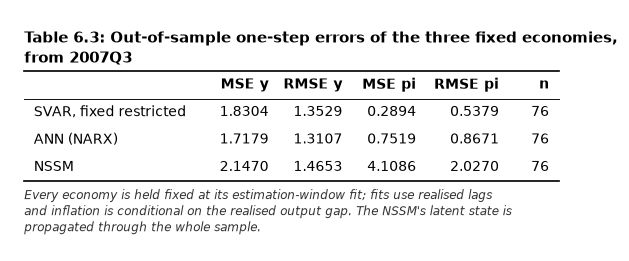

In [11]:
oos = fit_all.loc[cfg.oos_start :]
oos = oos.join(svar_fit[["y_hat", "pi_hat"]].add_suffix("_svar")).join(
    narx_fit[["y_hat", "pi_hat"]].add_suffix("_narx")
)
assert not oos.isna().any().any()

oos_metrics = pd.DataFrame({
    "SVAR, fixed restricted": lin.error_metrics(oos, "y_hat_svar", "pi_hat_svar"),
    "ANN (NARX)": lin.error_metrics(oos, "y_hat_narx", "pi_hat_narx"),
    "NSSM": lin.error_metrics(oos),
}).T
oos_metrics["n"] = oos_metrics["n"].astype(int)
oos_metrics.to_csv(nb.artifacts("nonlinear") / "oos_summary.csv")
nb.table(
    oos_metrics,
    "oos_error_metrics",
    f"Out-of-sample one-step errors of the three fixed economies, from {cfg.oos_start}",
    float_format="{:.4f}",
    note=(
        "Every economy is held fixed at its estimation-window fit; fits use realised lags and"
        " inflation is conditional on the realised output gap. The NSSM's latent state is"
        " propagated through the whole sample."
    ),
)

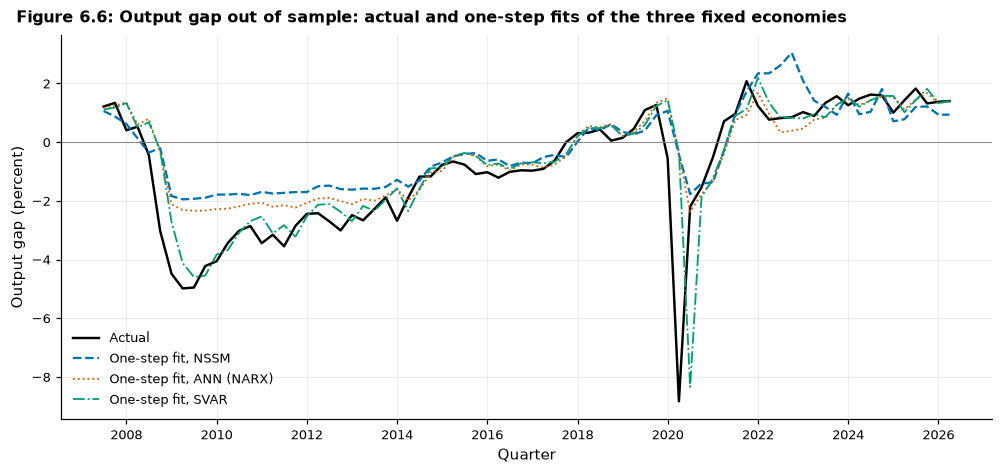

In [12]:
fig = plots.actual_vs_fit(
    oos,
    "y",
    {
        "One-step fit, NSSM": "y_hat",
        "One-step fit, ANN (NARX)": "y_hat_narx",
        "One-step fit, SVAR": "y_hat_svar",
    },
)
nb.figure(
    fig,
    "oos_output_gap",
    "Output gap out of sample: actual and one-step fits of the three fixed economies",
)

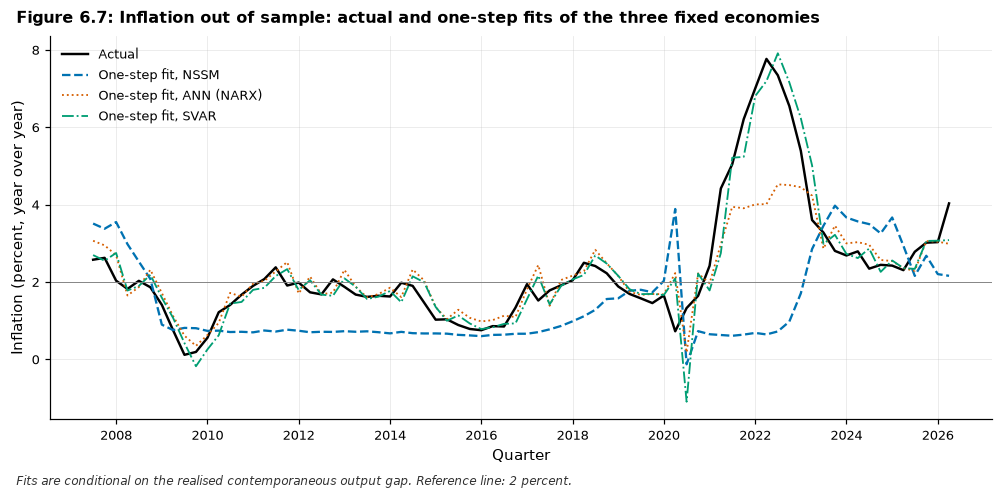

In [13]:
fig = plots.actual_vs_fit(
    oos,
    "pi",
    {
        "One-step fit, NSSM": "pi_hat",
        "One-step fit, ANN (NARX)": "pi_hat_narx",
        "One-step fit, SVAR": "pi_hat_svar",
    },
)
nb.figure(
    fig,
    "oos_inflation",
    "Inflation out of sample: actual and one-step fits of the three fixed economies",
    note=(
        "Fits are conditional on the realised contemporaneous output gap. Reference line: 2"
        " percent."
    ),
)

# References (APA)

## Software
1. Sunder, N. (2025). fedfred: A Python client for the Federal Reserve Economic Database (FRED) API (v3.0.0). Zenodo. https://doi.org/10.5281/zenodo.17635942

2. The pandas development team. (2026). pandas-dev/pandas: Pandas (v3.0.1). Zenodo. https://doi.org/10.5281/zenodo.18675244

3. Python Software Foundation. (2025). Python (Version 3.13.7) [Computer software]. Python Software Foundation. https://www.python.org/

4. The Matplotlib Development Team. (2025). Matplotlib: Visualization with Python (v3.10.8). Zenodo. https://doi.org/10.5281/zenodo.17595503

5. Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., Fernández del Río, J., Wiebe, M., Peterson, P., Gérard-Marchant, P., Sheppard, K., Reddy, T., Weckesser, W., Abbasi, H., Gohlke, C., & Oliphant, T. E. (2020). Array programming with NumPy. Nature, 585(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

6. Thomas, Kluyver & Benjamin, Ragan-Kelley & Fernando, Perez & Brian, Granger & Matthias, Bussonnier & Jonathan, Frederic & Kyle, Kelley & Jessica, Hamrick & Jason, Grout & Sylvain, Corlay & Paul, Ivanov & Damian, Avila & Safia, Abdalla & Carol, Willing & Team, Jupyter. (2016). Jupyter Notebooks – a publishing format for reproducible computational workflows. 10.3233/978-1-61499-649-1-87.

7. Ansel, J., Yang, E., He, H., Gimelshein, N., Jain, A., Voznesensky, M., Bao, B., Bell, P., Berard, D., Burovski, E., Chauhan, G., Chourdia, A., Constable, W., Desmaison, A., DeVito, Z., Ellison, E., Feng, W., Gong, J., Gschwind, M., Hirsh, B., Huang, S., Kalambarkar, K., Kirsch, L., Lazos, M., Lezcano, M., Liang, Y., Liang, J., Lu, Y., Luk, C., Maher, B., Pan, Y., Puhrsch, C., Reso, M., Saroufim, M., Siraichi, M. Y., Suk, H., Suo, M., Tillet, P., Wang, E., Wang, X., Wen, W., Zhang, S., Zhao, X., Zhou, K., Zou, R., Mathews, A., Chanan, G., Wu, P., & Chintala, S. (2024). PyTorch 2: Faster Machine Learning Through Dynamic Python Bytecode Transformation and Graph Compilation [Conference paper]. 29th ACM International Conference on Architectural Support for Programming Languages and Operating Systems, Volume 2 (ASPLOS '24). https://doi.org/10.1145/3620665.3640366

## Papers & Books
1. Chen, S., & Billings, S. A. (1992). Neural networks for nonlinear dynamic system modelling and identification. *International Journal of Control*, 56(2), 319–346. https://doi.org/10.1080/00207179208934317

2. Narendra, K. S., & Parthasarathy, K. (1990). Identification and control of dynamical systems using neural networks. *IEEE transactions on neural networks*, 1(1), 4–27. https://doi.org/10.1109/72.80202

3. Raiko, T., Valpola, H., & LeCun, Y. (2012). Deep Learning Made Easier by Linear Transformations in Perceptrons. *International Conference on Artificial Intelligence and Statistics*.

4. Nguyen, D., & Widrow, B. (1990). Neural Network for Self-Learning Control Systems. *Control Systems Magazine*, IEEE. 10. 18 - 23. https://doi.org/10.1109/37.55119.

5. Levenberg, K. (1944) A Method for the Solution of Certain Non-Linear Problems in Least Squares. *Quarterly of Applied Mathematics*, 2, 164-168. https://doi.org/10.1090/qam/10666

6. Marquardt, D. W. (1963). An Algorithm for Least-Squares Estimation of Nonlinear Parameters. *Journal of the Society for Industrial and Applied Mathematics*, 11(2), 431–441. http://www.jstor.org/stable/2098941

7. Aras, S., & Kocakoç, I. D. (2016). A new model selection strategy in time series forecasting with artificial neural networks. *IHTS. Neurocomputing.* 174. 10.1016/j.neucom.2015.10.036.

8. White, H. (1988). Economic prediction using neural networks: The case of IBM daily stock returns. *Proceedings of the IEEE International Conference on Neural Networks*, 2, 451–458.

9. Swanson, N. R., & White, H. (1997). A model selection approach to assessing the information in the term structure using linear models and artificial neural networks. *Journal of Business & Economic Statistics*, 15(4), 370–386.

10. Durbin, J., & Koopman, S. J. (2001). Time Series Analysis by State Space Methods. https://doi.org/10.1093/acprof:oso/9780199641178.001.0001

11. Fraccaro, M., & Sønderby, S., & Paquet, U., & Winther, O. (2016). Sequential Neural Models with Stochastic Layers. https://doi.org/10.48550/arXiv.1605.07571

12. Krishnan, R. G., Shalit, U., Sontag, D., (2017). Structured Inference Networks for Nonlinear State Space Models. https://doi.org/10.48550/arXiv.1609.09869

13. Rangapuram, S. S., Seeger, M., Gasthaus, J., Stella, L., Yuyang, Wang., Januschowski, T. (2018). Deep State Space Models for Time Series Forecasting. *NIPS'18: Proceedings of the 32nd International Conference on Neural Information Processing Systems*, 7796-7805.

14. Elfwing, S., & Uchibe, Eiji & Doya, Kenji. (2018). Unbounded Output Networks for Classification. https://doi.org/10.48550/arXiv.1807.09443

15. Ramachandran, P., Zoph, B., & Le, Q.V. (2018). Searching for Activation Functions. *ArXiv*, https://doi.org/abs/1710.05941

16. Saxe, A., & Mcclelland, J., & Ganguli, S. (2013). Exact solutions to the nonlinear dynamics of learning in deep linear neural networks. https://doi.org/10.48550/arXiv.1312.6120

17. Hu, W., Xiao, L., & Pennington, J. (2020). Provable Benefit of Orthogonal Initialization in Optimizing Deep Linear Networks. *ArXiv*, https://doi.org/abs/2001.05992

18. Glorot, X., & Bengio, Y. (2010). Understanding the difficulty of training deep feedforward neural networks. *International Conference on Artificial Intelligence and Statistics*.

19. Loshchilov, I., & Hutter, F. (2017). Decoupled Weight Decay Regularization. *International Conference on Learning Representations*. https://doi.org/10.48550/arXiv.1711.05101

# Export

The last cell converts this notebook to PDF in the shared `documents/` directory. A kernel can only
convert the copy saved on disk, so the cell waits briefly for the editor to save; if the file is still
behind, it writes nothing and asks you to save and run it again.

In [14]:
nb.export_pdf()

/var/folders/cj/p5jdwnb923752l7zjc_69j5w0000gn/T/ipykernel_3366/281924391.py:1: UserWarning: 06_nonlinear_nssm.ipynb on disk does not yet contain this run's outputs, so no PDF was written. Save the notebook and run this cell again.
  nb.export_pdf()
